In [7]:
import numpy as np
import pandas as pd

df = pd.read_excel('default of credit card clients.xls', header=1)

print(df.shape)
df.head()

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [8]:
print(df['default payment next month'].value_counts())
print(df['default payment next month'].value_counts(normalize=True))

default payment next month
0    23364
1     6636
Name: count, dtype: int64
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [9]:
print("EDUCATION values:")
print(df['EDUCATION'].value_counts())

print("\nMARRIAGE values:")
print(df['MARRIAGE'].value_counts())

print("\nPAY_0 values:")
print(df['PAY_0'].value_counts().sort_index())

EDUCATION values:
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

MARRIAGE values:
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

PAY_0 values:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


In [10]:
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print(df['EDUCATION'].value_counts())
print(df['MARRIAGE'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


In [11]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
payamt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# --- Payment history features ---
df['avg_delay'] = df[pay_cols].mean(axis=1)
df['max_delay'] = df[pay_cols].max(axis=1)
df['months_delayed'] = (df[pay_cols] > 0).sum(axis=1)

# --- Credit utilization features ---
df['avg_bill'] = df[bill_cols].mean(axis=1)
df['avg_utilization'] = df['avg_bill'] / df['LIMIT_BAL'].replace(0, np.nan)

# --- Bill trend: is debt growing or shrinking over the 6 months? ---
df['bill_trend'] = df['BILL_AMT1'] - df['BILL_AMT6']

# --- Payment behavior: how much of their bill are they actually paying off? ---
df['avg_payment'] = df[payamt_cols].mean(axis=1)
df['payment_ratio'] = df['avg_payment'] / df['avg_bill'].replace(0, np.nan)

print(df[['avg_delay', 'max_delay', 'months_delayed', 'avg_utilization', 'bill_trend', 'payment_ratio']].describe())

          avg_delay     max_delay  months_delayed  avg_utilization  \
count  30000.000000  30000.000000    30000.000000     30000.000000   
mean      -0.182439      0.438733        0.834200         0.373048   
std        0.982176      1.345154        1.554303         0.351890   
min       -2.000000     -2.000000        0.000000        -0.232590   
25%       -0.833333      0.000000        0.000000         0.029997   
50%        0.000000      0.000000        0.000000         0.284834   
75%        0.000000      2.000000        1.000000         0.687929   
max        6.000000      8.000000        6.000000         5.364308   

          bill_trend  payment_ratio  
count   30000.000000   29130.000000  
mean    12351.570500       0.392318  
std     43922.421534       7.784430  
min   -428791.000000    -546.928571  
25%     -2963.000000       0.042188  
50%       923.000000       0.092133  
75%     19793.750000       0.615363  
max    708323.000000     797.000000  


In [12]:
# a real client example
example = df.iloc[0]

months = ['April', 'May', 'June', 'July', 'August', 'September']
pay_status = [example['PAY_6'], example['PAY_5'], example['PAY_4'], example['PAY_3'], example['PAY_2'], example['PAY_0']]
bills = [example['BILL_AMT6'], example['BILL_AMT5'], example['BILL_AMT4'], example['BILL_AMT3'], example['BILL_AMT2'], example['BILL_AMT1']]
payments = [example['PAY_AMT6'], example['PAY_AMT5'], example['PAY_AMT4'], example['PAY_AMT3'], example['PAY_AMT2'], example['PAY_AMT1']]

statement = pd.DataFrame({
    'Month': months,
    'Bill amount (owed)': bills,
    'Amount paid': payments,
    'Lateness status': pay_status
})

print(f"Client ID: {example['ID']}  |  Credit limit: {example['LIMIT_BAL']}  |  Age: {example['AGE']}  |  Defaulted next month: {example['default payment next month']}")
print(statement)

Client ID: 1.0  |  Credit limit: 20000.0  |  Age: 24.0  |  Defaulted next month: 1.0
       Month  Bill amount (owed)  Amount paid  Lateness status
0      April                 0.0          0.0             -2.0
1        May                 0.0          0.0             -2.0
2       June                 0.0          0.0             -1.0
3       July               689.0          0.0             -1.0
4     August              3102.0        689.0              2.0
5  September              3913.0          0.0              2.0


In [13]:
# Checking how many rows are actually causing the extreme values
extreme_low = (df['payment_ratio'] < 0).sum()
extreme_high = (df['payment_ratio'] > 3).sum()
print(f"Rows with negative payment_ratio: {extreme_low}")
print(f"Rows with payment_ratio > 3: {extreme_high}")

# Cap the ratio: 0 = paid nothing, 3 = paid 3x their average bill
df['payment_ratio'] = df['payment_ratio'].clip(lower=0, upper=3)

# Missing values (from 0/0 divisions) — fill with 0, meaning "no clear bill to measure against"
df['payment_ratio'] = df['payment_ratio'].fillna(0)

print(df['payment_ratio'].describe())

Rows with negative payment_ratio: 127
Rows with payment_ratio > 3: 272
count    30000.000000
mean         0.356841
std          0.503140
min          0.000000
25%          0.040952
50%          0.084932
75%          0.586922
max          3.000000
Name: payment_ratio, dtype: float64


In [14]:
extreme_neg_util = (df['avg_utilization'] < 0).sum()
extreme_high_util = (df['avg_utilization'] > 2).sum()
print(f"Rows with negative utilization: {extreme_neg_util}")
print(f"Rows with utilization > 2 (200%+): {extreme_high_util}")

df['avg_utilization'] = df['avg_utilization'].clip(lower=0, upper=2)

print(df['avg_utilization'].describe())

Rows with negative utilization: 201
Rows with utilization > 2 (200%+): 15
count    30000.000000
mean         0.372851
std          0.349678
min          0.000000
25%          0.029997
50%          0.284834
75%          0.687929
max          2.000000
Name: avg_utilization, dtype: float64


In [15]:
df = pd.get_dummies(df, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month', 'avg_delay', 'max_delay', 'months_delayed', 'avg_bill', 'avg_utilization', 'bill_trend', 'avg_payment', 'payment_ratio', 'SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']


In [16]:
# Drop ID (not predictive) and the target itself from the features
X = df.drop(columns=['ID', 'default payment next month'])
y = df['default payment next month']

print(X.shape, y.shape)
print(X.columns.tolist())

(30000, 34) (30000,)
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'avg_delay', 'max_delay', 'months_delayed', 'avg_bill', 'avg_utilization', 'bill_trend', 'avg_payment', 'payment_ratio', 'SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Train default rate: 0.22120833333333334
Test default rate: 0.22116666666666668


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]



In [27]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.95      0.88      4673
           1       0.64      0.30      0.40      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.62      0.64      6000
weighted avg       0.78      0.81      0.78      6000

ROC-AUC: 0.7441403267274316
Confusion Matrix:
[[4451  222]
 [ 935  392]]


In [26]:
log_reg_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = log_reg_balanced.predict(X_test_scaled)
y_pred_proba_balanced = log_reg_balanced.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_balanced))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.87      0.78      0.83      4673
           1       0.44      0.60      0.51      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.74      0.76      6000

ROC-AUC: 0.746969837952186
Confusion Matrix:
[[3659 1014]
 [ 529  798]]


In [28]:
# Trying a lower threshold
threshold = 0.3
y_pred_thresh = (y_pred_proba >= threshold).astype(int)

print(f"--- Original model, threshold = {threshold} ---")
print(classification_report(y_test, y_pred_thresh))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_thresh))

--- Original model, threshold = 0.3 ---
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      4673
           1       0.50      0.53      0.52      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.69      0.69      6000
weighted avg       0.79      0.78      0.78      6000

Confusion Matrix:
[[3980  693]
 [ 622  705]]


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4673
           1       0.48      0.61      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000

ROC-AUC: 0.7771163239382358
Confusion Matrix:
[[3796  877]
 [ 517  810]]


            feature  importance
2             PAY_0    0.140012
22   months_delayed    0.130446
21        max_delay    0.124624
20        avg_delay    0.103098
3             PAY_2    0.043019
4             PAY_3    0.035760
26      avg_payment    0.032202
24  avg_utilization    0.028191
0         LIMIT_BAL    0.026593
5             PAY_4    0.025063
27    payment_ratio    0.023522
14         PAY_AMT1    0.023169
15         PAY_AMT2    0.022432
23         avg_bill    0.020847
8         BILL_AMT1    0.020183


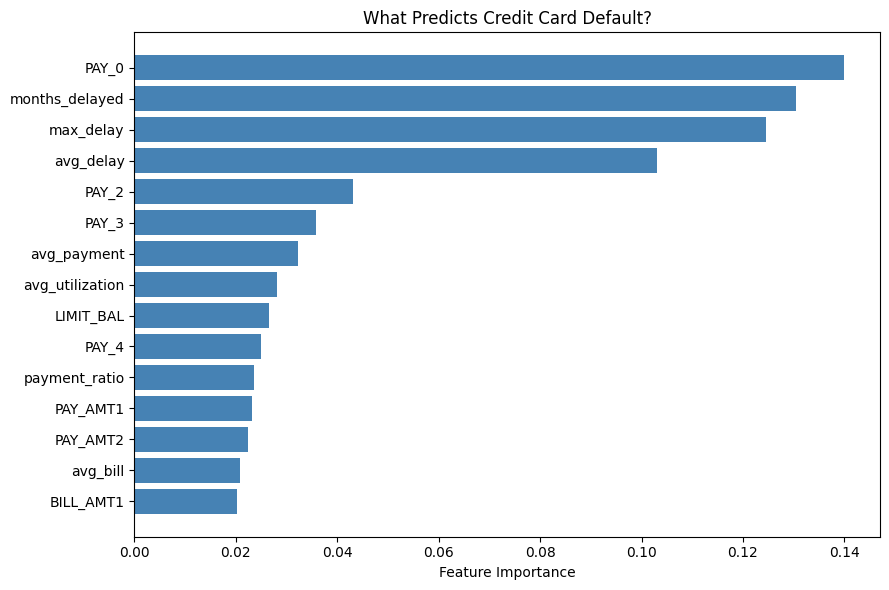

In [30]:
import matplotlib.pyplot as plt

importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(15))

plt.figure(figsize=(9, 6))
plt.barh(importances['feature'][:15], importances['importance'][:15], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('What Predicts Credit Card Default?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [31]:
# Pull the real avg_bill values for the test set, aligned to predictions
test_bills = X_test['avg_bill'].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

def estimate_cost(y_true, y_pred, bills, fp_cost_rate=0.10):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    false_negatives = (y_true == 1) & (y_pred == 0)
    false_positives = (y_true == 0) & (y_pred == 1)

    fn_cost = bills[false_negatives].sum()          # full bill amount lost per missed defaulter
    fp_cost = (bills[false_positives] * fp_cost_rate).sum()  # smaller lost-revenue cost per false alarm

    total_cost = fn_cost + fp_cost
    return fn_cost, fp_cost, total_cost, false_negatives.sum(), false_positives.sum()

# Compare all four approaches
models_preds = {
    'Logistic Regression (0.5 threshold)': y_pred,
    'Logistic Regression (balanced)': y_pred_balanced,
    'Logistic Regression (threshold 0.3)': y_pred_thresh,
    'Random Forest (balanced)': y_pred_rf
}

results = []
for name, preds in models_preds.items():
    fn_cost, fp_cost, total, n_fn, n_fp = estimate_cost(y_test, preds, test_bills)
    results.append({'Model': name, 'False Negatives': n_fn, 'FN Cost (£)': fn_cost,
                     'False Positives': n_fp, 'FP Cost (£)': fp_cost, 'Total Estimated Cost (£)': total})

cost_df = pd.DataFrame(results)
print(cost_df.to_string(index=False))

                              Model  False Negatives  FN Cost (£)  False Positives  FP Cost (£)  Total Estimated Cost (£)
Logistic Regression (0.5 threshold)              935   39926268.0              222 1.009578e+06              4.093585e+07
     Logistic Regression (balanced)              529   22039465.0             1014 3.647984e+06              2.568745e+07
Logistic Regression (threshold 0.3)              622   25247035.5              693 2.536301e+06              2.778334e+07
           Random Forest (balanced)              517   23043824.5              877 3.186722e+06              2.623055e+07


In [32]:
# Quick sensitivity check: does the ranking hold under a different FP cost assumption?
for rate in [0.05, 0.10, 0.20, 0.30]:
    print(f"\n--- FP cost rate = {rate} ---")
    for name, preds in models_preds.items():
        _, _, total, _, _ = estimate_cost(y_test, preds, test_bills, fp_cost_rate=rate)
        print(f"{name}: NT${total:,.0f}")


--- FP cost rate = 0.05 ---
Logistic Regression (0.5 threshold): NT$40,431,057
Logistic Regression (balanced): NT$23,863,457
Logistic Regression (threshold 0.3): NT$26,515,186
Random Forest (balanced): NT$24,637,186

--- FP cost rate = 0.1 ---
Logistic Regression (0.5 threshold): NT$40,935,846
Logistic Regression (balanced): NT$25,687,448
Logistic Regression (threshold 0.3): NT$27,783,337
Random Forest (balanced): NT$26,230,547

--- FP cost rate = 0.2 ---
Logistic Regression (0.5 threshold): NT$41,945,424
Logistic Regression (balanced): NT$29,335,432
Logistic Regression (threshold 0.3): NT$30,319,638
Random Forest (balanced): NT$29,417,269

--- FP cost rate = 0.3 ---
Logistic Regression (0.5 threshold): NT$42,955,002
Logistic Regression (balanced): NT$32,983,416
Logistic Regression (threshold 0.3): NT$32,855,939
Random Forest (balanced): NT$32,603,991


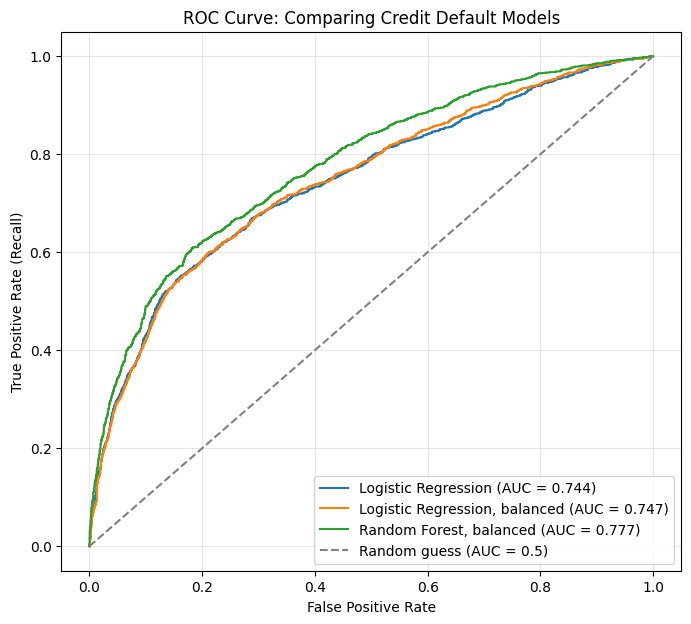

In [33]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 7))

# Logistic Regression (original, 0.5 threshold model - same underlying probabilities)
fpr1, tpr1, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr1, tpr1, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')

# Logistic Regression (balanced)
fpr2, tpr2, _ = roc_curve(y_test, y_pred_proba_balanced)
plt.plot(fpr2, tpr2, label=f'Logistic Regression, balanced (AUC = {roc_auc_score(y_test, y_pred_proba_balanced):.3f})')

# Random Forest
fpr3, tpr3, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr3, tpr3, label=f'Random Forest, balanced (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.3f})')

# Diagonal reference line = random guessing
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Comparing Credit Default Models')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [34]:
# Combine metrics into one clean export table
export_summary = pd.DataFrame({
    'Model': ['Logistic Regression (0.5 threshold)', 'Logistic Regression (balanced)',
              'Logistic Regression (threshold 0.3)', 'Random Forest (balanced)'],
    'ROC_AUC': [0.744, 0.747, 0.744, 0.777],
    'Recall_Class1': [0.30, 0.60, 0.53, 0.61],
    'Precision_Class1': [0.64, 0.44, 0.50, 0.48],
    'False_Negatives': cost_df['False Negatives'].values,
    'False_Positives': cost_df['False Positives'].values,
    'Estimated_Cost_NTD': cost_df['Total Estimated Cost (£)'].values
})

export_summary.to_csv('credit_risk_model_comparison.csv', index=False)

from google.colab import files
files.download('credit_risk_model_comparison.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>